# Refinement Analysis: Understanding the Self-Refinement Process

This notebook analyzes the results from running refinement on 200 examples from the documents_train.csv dataset. We'll explore various aspects of the refinement process to understand how the system improves text quality over iterations.

##### TODO

* check example_015, original id: 2bbfadc4-a0dc-466f-9b20-1fddbe564437
* in what iteration did we get the best score
* mix model - run on examples 32 and 15 with claude as the task llm
* personalization

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
# refinement results file path
csv_path = Path("../../r_50_5.csv")

In [3]:
# Set up plotting style
plt.style.use('default')
sns.set_palette("deep")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## Refinement Results


In [4]:
df = pd.read_csv(csv_path)

print(f"Loaded {len(df)} rows from {csv_path}")
print(f"Columns: {list(df.columns)}")
print(f"Data shape: {df.shape}")
print(f"Number of unique examples: {df['example_id'].nunique()}")

df.head()

Loaded 210 rows from ../../r_50_5.csv
Columns: ['example_id', 'original_id', 'title', 'profession', 'purpose', 'original_text_length', 'iteration_number', 'structure_score', 'coverage_score', 'focus_relevance_score', 'redundancy_score', 'combined_score', 'structure_reasoning', 'coverage_reasoning', 'focus_relevance_reasoning', 'redundancy_reasoning', 'combined_feedback', 'output', 'refinement_reasoning', 'is_final_iteration', 'converged_early', 'total_iterations', 'current_best_score', 'current_best_iteration']
Data shape: (210, 24)
Number of unique examples: 50


,example_id,original_id,title,profession,purpose,original_text_length,iteration_number,structure_score,coverage_score,focus_relevance_score,...,focus_relevance_reasoning,redundancy_reasoning,combined_feedback,output,refinement_reasoning,is_final_iteration,converged_early,total_iterations,current_best_score,current_best_iteration
0,example_001,0a0da134-7181-4675-b06e-be176a16605e,Introduction,researcher/academia,work,2510,1,0.85,1.00,1.00,...,The restructured text maintains a strong focus...,"The output text contains some redundancy, part...",- Add a one-line summary immediately after the...,# Text Entry on Smartwatches: Challenges and R...,"To address the feedback, I added a one-line su...",False,False,2,0.8875,1
1,example_001,0a0da134-7181-4675-b06e-be176a16605e,Introduction,researcher/academia,work,2510,2,1.00,1.00,1.00,...,The restructured text remains focused and rele...,The output text contains several instances of ...,NaN,# Smartwatch Text Entry Challenges and Researc...,NaN,True,True,2,0.9775,2
2,example_002,d6eb3f67-abdc-401a-98bc-4923623f69fd,Philosophy Program Struggles,researcher/academia,school,1857,1,0.85,0.85,0.85,...,The restructured text maintains a focus on the...,The output text contains several instances of ...,- Add a one-line summary to concisely summariz...,# Challenges in Academic Program Assessments\n...,"To address the feedback, I added a one-line su...",False,False,5,0.8125,1
3,example_002,d6eb3f67-abdc-401a-98bc-4923623f69fd,Philosophy Program Struggles,researcher/academia,school,1857,2,0.85,0.85,0.95,...,The restructured text maintains a strong focus...,"The output text contains some redundancy, part...",- Fix the one-line summary to ensure it does n...,# Challenges in Academic Program Assessments\n...,"To address the feedback, I made several change...",False,False,5,0.8500,2
4,example_002,d6eb3f67-abdc-401a-98bc-4923623f69fd,Philosophy Program Struggles,researcher/academia,school,1857,3,0.85,1.00,1.00,...,The restructured text remains focused on the o...,"The output text contains some redundancy, part...",- Fix the one-line summary to ensure it does n...,# Challenges in Academic Program Assessments\n...,"To address the feedback, I made the following ...",False,False,5,0.8875,3


In [5]:
df

,example_id,original_id,title,profession,purpose,original_text_length,iteration_number,structure_score,coverage_score,focus_relevance_score,...,focus_relevance_reasoning,redundancy_reasoning,combined_feedback,output,refinement_reasoning,is_final_iteration,converged_early,total_iterations,current_best_score,current_best_iteration
0,example_001,0a0da134-7181-4675-b06e-be176a16605e,Introduction,researcher/academia,work,2510,1,0.85,1.00,1.00,...,The restructured text maintains a strong focus...,"The output text contains some redundancy, part...",- Add a one-line summary immediately after the...,# Text Entry on Smartwatches: Challenges and R...,"To address the feedback, I added a one-line su...",False,False,2,0.8875,1
1,example_001,0a0da134-7181-4675-b06e-be176a16605e,Introduction,researcher/academia,work,2510,2,1.00,1.00,1.00,...,The restructured text remains focused and rele...,The output text contains several instances of ...,NaN,# Smartwatch Text Entry Challenges and Researc...,NaN,True,True,2,0.9775,2
2,example_002,d6eb3f67-abdc-401a-98bc-4923623f69fd,Philosophy Program Struggles,researcher/academia,school,1857,1,0.85,0.85,0.85,...,The restructured text maintains a focus on the...,The output text contains several instances of ...,- Add a one-line summary to concisely summariz...,# Challenges in Academic Program Assessments\n...,"To address the feedback, I added a one-line su...",False,False,5,0.8125,1
3,example_002,d6eb3f67-abdc-401a-98bc-4923623f69fd,Philosophy Program Struggles,researcher/academia,school,1857,2,0.85,0.85,0.95,...,The restructured text maintains a strong focus...,"The output text contains some redundancy, part...",- Fix the one-line summary to ensure it does n...,# Challenges in Academic Program Assessments\n...,"To address the feedback, I made several change...",False,False,5,0.8500,2
4,example_002,d6eb3f67-abdc-401a-98bc-4923623f69fd,Philosophy Program Struggles,researcher/academia,school,1857,3,0.85,1.00,1.00,...,The restructured text remains focused on the o...,"The output text contains some redundancy, part...",- Fix the one-line summary to ensure it does n...,# Challenges in Academic Program Assessments\n...,"To address the feedback, I made the following ...",False,False,5,0.8875,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,example_050,fc7684ab-6d24-437a-86d6-c81fb2631bc2,"Director, Product Management - Data Strategy, ...",it specialist,work,1099,1,0.85,0.85,1.00,...,The restructured text maintains a clear focus ...,"The output text contains some redundancy, part...",- Add a one-line summary immediately after the...,# Multi-Cloud Strategy and Data Integration\n\...,"To address the feedback, I made several change...",False,False,5,0.8500,1
206,example_050,fc7684ab-6d24-437a-86d6-c81fb2631bc2,"Director, Product Management - Data Strategy, ...",it specialist,work,1099,2,0.65,1.00,1.00,...,The restructured text remains focused and rele...,The output text contains several instances of ...,"- Remove the multiple instances of ""Summary"" u...",# Multi-Cloud Strategy and Data Integration\n\...,"To address the feedback, I removed the redunda...",False,False,5,0.8500,1
207,example_050,fc7684ab-6d24-437a-86d6-c81fb2631bc2,"Director, Product Management - Data Strategy, ...",it specialist,work,1099,3,1.00,1.00,1.00,...,The restructured text maintains a strong focus...,The output text contains some redundancy in th...,- Remove redundancy in the Overview section by...,# Multi-Cloud Strategy and Data Integration\n\...,To address the feedback regarding redundancy a...,False,False,5,0.9625,3
208,example_050,fc7684ab-6d24-437a-86d6-c81fb2631bc2,"Director, Product Management - Data Strategy, ...",it specialist,work,1099,4,1.00,1.00,1.00,...,The restructured text remains highly focused a...,The output text is identical to the input text...,- Remove redundancy by summarizing key points ...,# Multi-Cloud Strategy and Data Integration\n\...,To address the feedback regarding redu

In [6]:
profession_counts = df[df['is_final_iteration'] == True]['profession'].value_counts()
profession_percentages = profession_counts / profession_counts.sum() * 100

# Calculate average, variance, and std of final score for each profession
final_iterations = df[df['is_final_iteration'] == True]
avg_score_by_profession = final_iterations.groupby('profession')['current_best_score'].mean()
var_score_by_profession = final_iterations.groupby('profession')['current_best_score'].var()
std_score_by_profession = final_iterations.groupby('profession')['current_best_score'].std()

profession_df = pd.DataFrame({
    'profession': profession_counts.index,
    'count': profession_counts.values,
    'percentage': profession_percentages.values,
    'average_final_score': [avg_score_by_profession.get(prof, float('nan')) for prof in profession_counts.index],
    'variance_final_score': [var_score_by_profession.get(prof, float('nan')) for prof in profession_counts.index],
    'std_final_score': [std_score_by_profession.get(prof, float('nan')) for prof in profession_counts.index]
})
# Add rolling percentage column
profession_df['rolling_percentage'] = profession_df['percentage'].cumsum()
print("Profession counts, percentages, average final score, variance, and std of final score:")
print(profession_df)


Profession counts, percentages, average final score, variance, and std of final score:
                     profession  count  percentage  average_final_score  \
0           researcher/academia     21        42.0             0.961071   
1                 it specialist      7        14.0             0.952500   
2                    journalist      5        10.0             0.955000   
3              teacher/lecturer      2         4.0             0.981250   
4   customer service specialist      2         4.0             0.962500   
5                        author      2         4.0             0.962500   
6                  data analyst      2         4.0             0.977500   
7                      marketer      2         4.0             0.928750   
8                  psychologist      1         2.0             0.902500   
9      customer success manager      1         2.0             0.962500   
10            manager/executive      1         2.0             0.962500   
11           

In [7]:
profession_df

,profession,count,percentage,average_final_score,variance_final_score,std_final_score,rolling_percentage
0,researcher/academia,21,42.0,0.961071,0.001331,0.036483,42.0
1,it specialist,7,14.0,0.952500,0.001269,0.035620,56.0
2,journalist,5,10.0,0.955000,0.000478,0.021866,66.0
3,teacher/lecturer,2,4.0,0.981250,0.000028,0.005303,70.0
4,customer service specialist,2,4.0,0.962500,0.000000,0.000000,74.0
5,author,2,4.0,0.962500,0.000000,0.000000,78.0
6,data analyst,2,4.0,0.977500,0.000000,0.000000,82.0
7,marketer,2,4.0,0.928750,0.004753,0.068943,86.0
8,psychologist,1,2.0,0.902500,NaN,NaN,88.0
9,customer success manager,1,2.0,0.962500,NaN,NaN,90.0


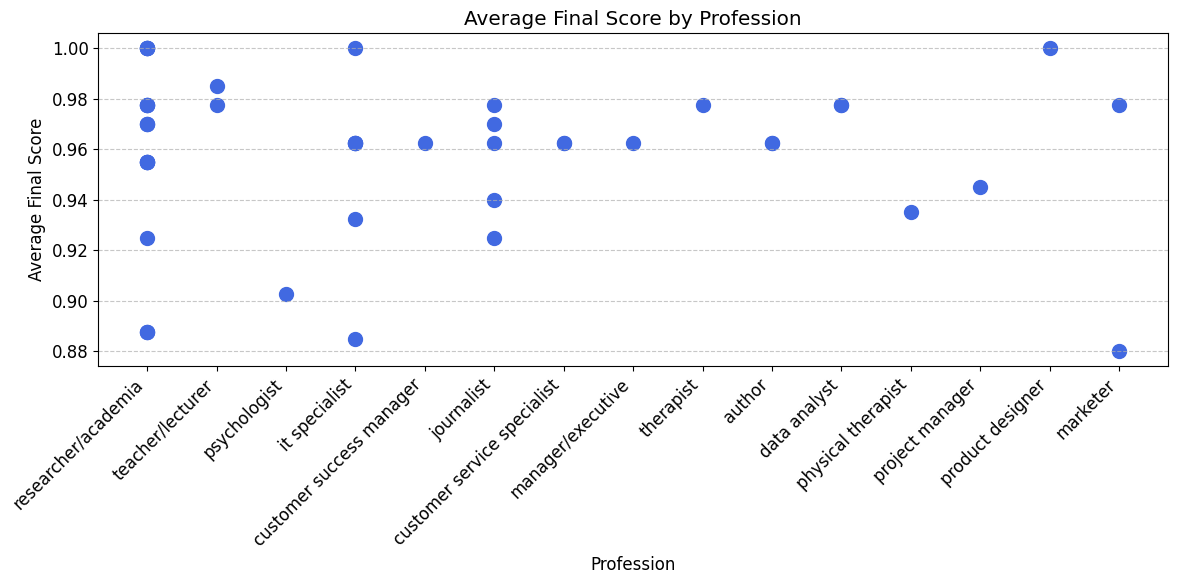

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.scatter(final_iterations['profession'], final_iterations['current_best_score'], color='royalblue', s=100)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Profession')
plt.ylabel('Average Final Score')
plt.title('Average Final Score by Profession')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


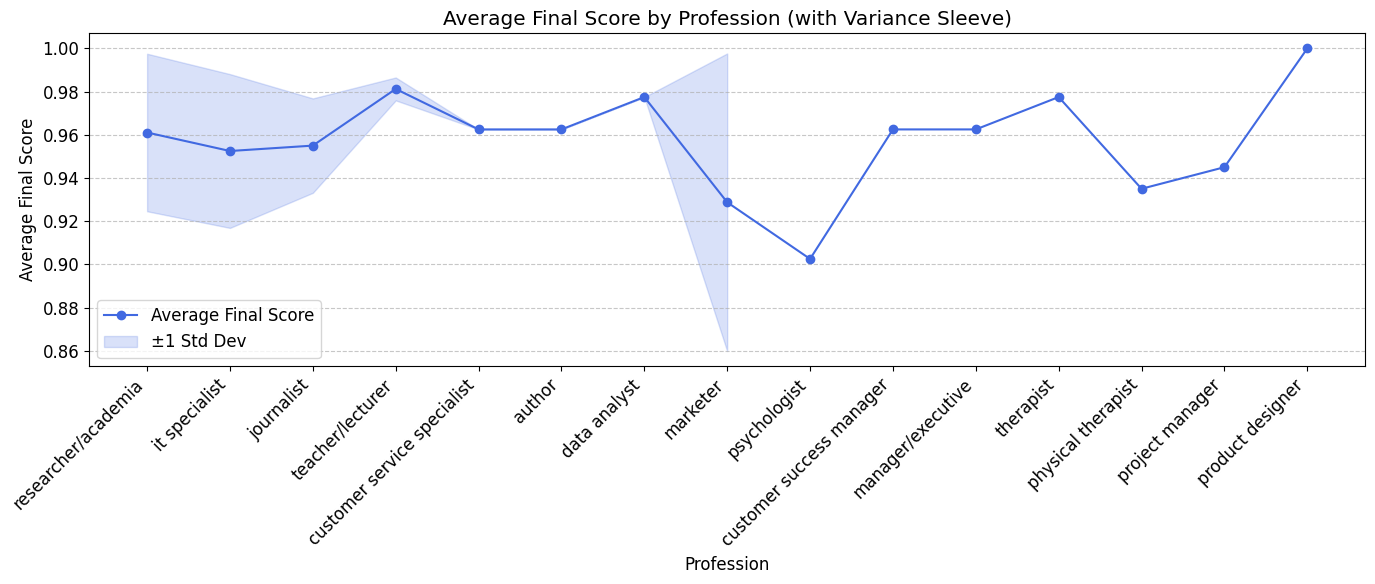

In [9]:
import numpy as np

plt.figure(figsize=(14, 6))
x = np.arange(len(profession_df['profession']))
y = profession_df['average_final_score']
yerr = profession_df['std_final_score']

plt.plot(x, y, marker='o', color='royalblue', label='Average Final Score')
plt.fill_between(x, y - yerr, y + yerr, color='royalblue', alpha=0.2, label='±1 Std Dev')

plt.xticks(x, profession_df['profession'], rotation=45, ha='right')
plt.xlabel('Profession')
plt.ylabel('Average Final Score')
plt.title('Average Final Score by Profession (with Variance Sleeve)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


## Basic Statistics and Overview

First, let's get a simple overview of our refinement data.  
We'll focus on the rows that show the results from the final iteration for each example.

In [10]:
final_iterations = df[df['is_final_iteration'] == True]

print("📈 BASIC STATISTICS")
print("=" * 50)
print(f"Total examples processed: {len(final_iterations)}")
print(f"Total iterations across all examples: {len(df)}")
print(f"Average iterations per example: {df.groupby('example_id')['iteration_number'].max().mean():.2f}")
print(f"Average final score: {final_iterations['current_best_score'].mean():.3f}")
print(f"Standard deviation of final scores: {final_iterations['current_best_score'].std():.3f}")
print(f"Range of final scores: {final_iterations['current_best_score'].min():.3f} - {final_iterations['current_best_score'].max():.3f}")

# convergence statistics
converged_early = len(final_iterations[final_iterations['converged_early'] == True])
convergence_rate = converged_early / len(final_iterations)
print(f"\n🎯 CONVERGENCE STATISTICS")
print("=" * 50)
print(f"Examples that converged early: {converged_early}")
print(f"Convergence rate: {convergence_rate:.2%}")
print(f"Examples that reached max iterations: {len(final_iterations) - converged_early}")

📈 BASIC STATISTICS
Total examples processed: 50
Total iterations across all examples: 210
Average iterations per example: 4.20
Average final score: 0.959
Standard deviation of final scores: 0.032
Range of final scores: 0.880 - 1.000

🎯 CONVERGENCE STATISTICS
Examples that converged early: 22
Convergence rate: 44.00%
Examples that reached max iterations: 28


## Score Trends Across Iterations

This is one of the most interesting aspects - how do scores improve over iterations?

In [11]:
avg_scores_by_iteration = df.groupby('iteration_number').agg({
    'current_best_score': 'mean',
    'structure_score': 'mean',
    'coverage_score': 'mean',
    'focus_relevance_score': 'mean',
    'redundancy_score': 'mean',
    'combined_score': 'mean',
}).reset_index()

print("📊 AVERAGE SCORES BY ITERATION")
print("=" * 50)
avg_scores_by_iteration.round(3)

📊 AVERAGE SCORES BY ITERATION


,iteration_number,current_best_score,structure_score,coverage_score,focus_relevance_score,redundancy_score,combined_score
0,1,0.884,0.892,0.898,0.997,0.725,0.884
1,2,0.927,0.911,0.967,0.988,0.757,0.911
2,3,0.938,0.916,0.984,0.988,0.690,0.906
3,4,0.943,0.909,0.970,0.986,0.635,0.892
4,5,0.944,0.906,0.975,0.981,0.698,0.900


Let's look at how the scores change in each iteration using a graph:

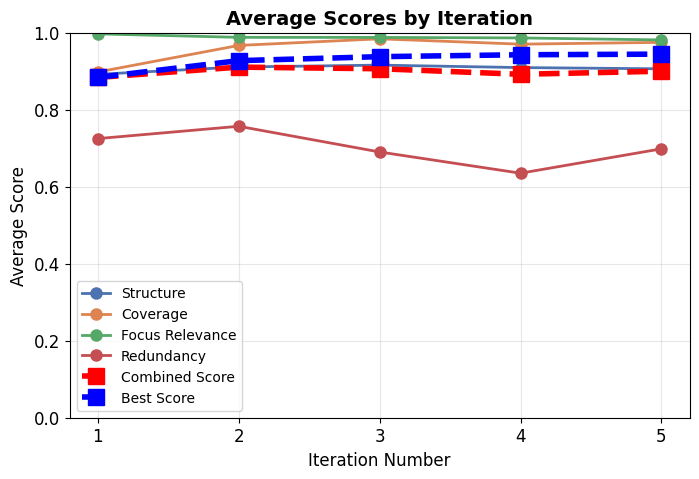

In [12]:
plt.figure(figsize=(8, 5))

for score_col in ['structure_score', 'coverage_score', 'focus_relevance_score', 'redundancy_score']:
    plt.plot(avg_scores_by_iteration['iteration_number'], 
             avg_scores_by_iteration[score_col], 
             marker='o', linewidth=2, markersize=8,
             label=score_col.replace('_score', '').replace('_', ' ').title())

plt.plot(avg_scores_by_iteration['iteration_number'], 
         avg_scores_by_iteration['combined_score'], 
         marker='s', color='red', linewidth=4, markersize=12, linestyle='--',
         label='Combined Score')

plt.plot(avg_scores_by_iteration['iteration_number'], 
         avg_scores_by_iteration['current_best_score'], 
         marker='s', color='blue', linewidth=4, markersize=12, linestyle='--',
         label='Best Score')

plt.xlabel('Iteration Number', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.title('Average Scores by Iteration', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.xticks(avg_scores_by_iteration['iteration_number'])
plt.show()

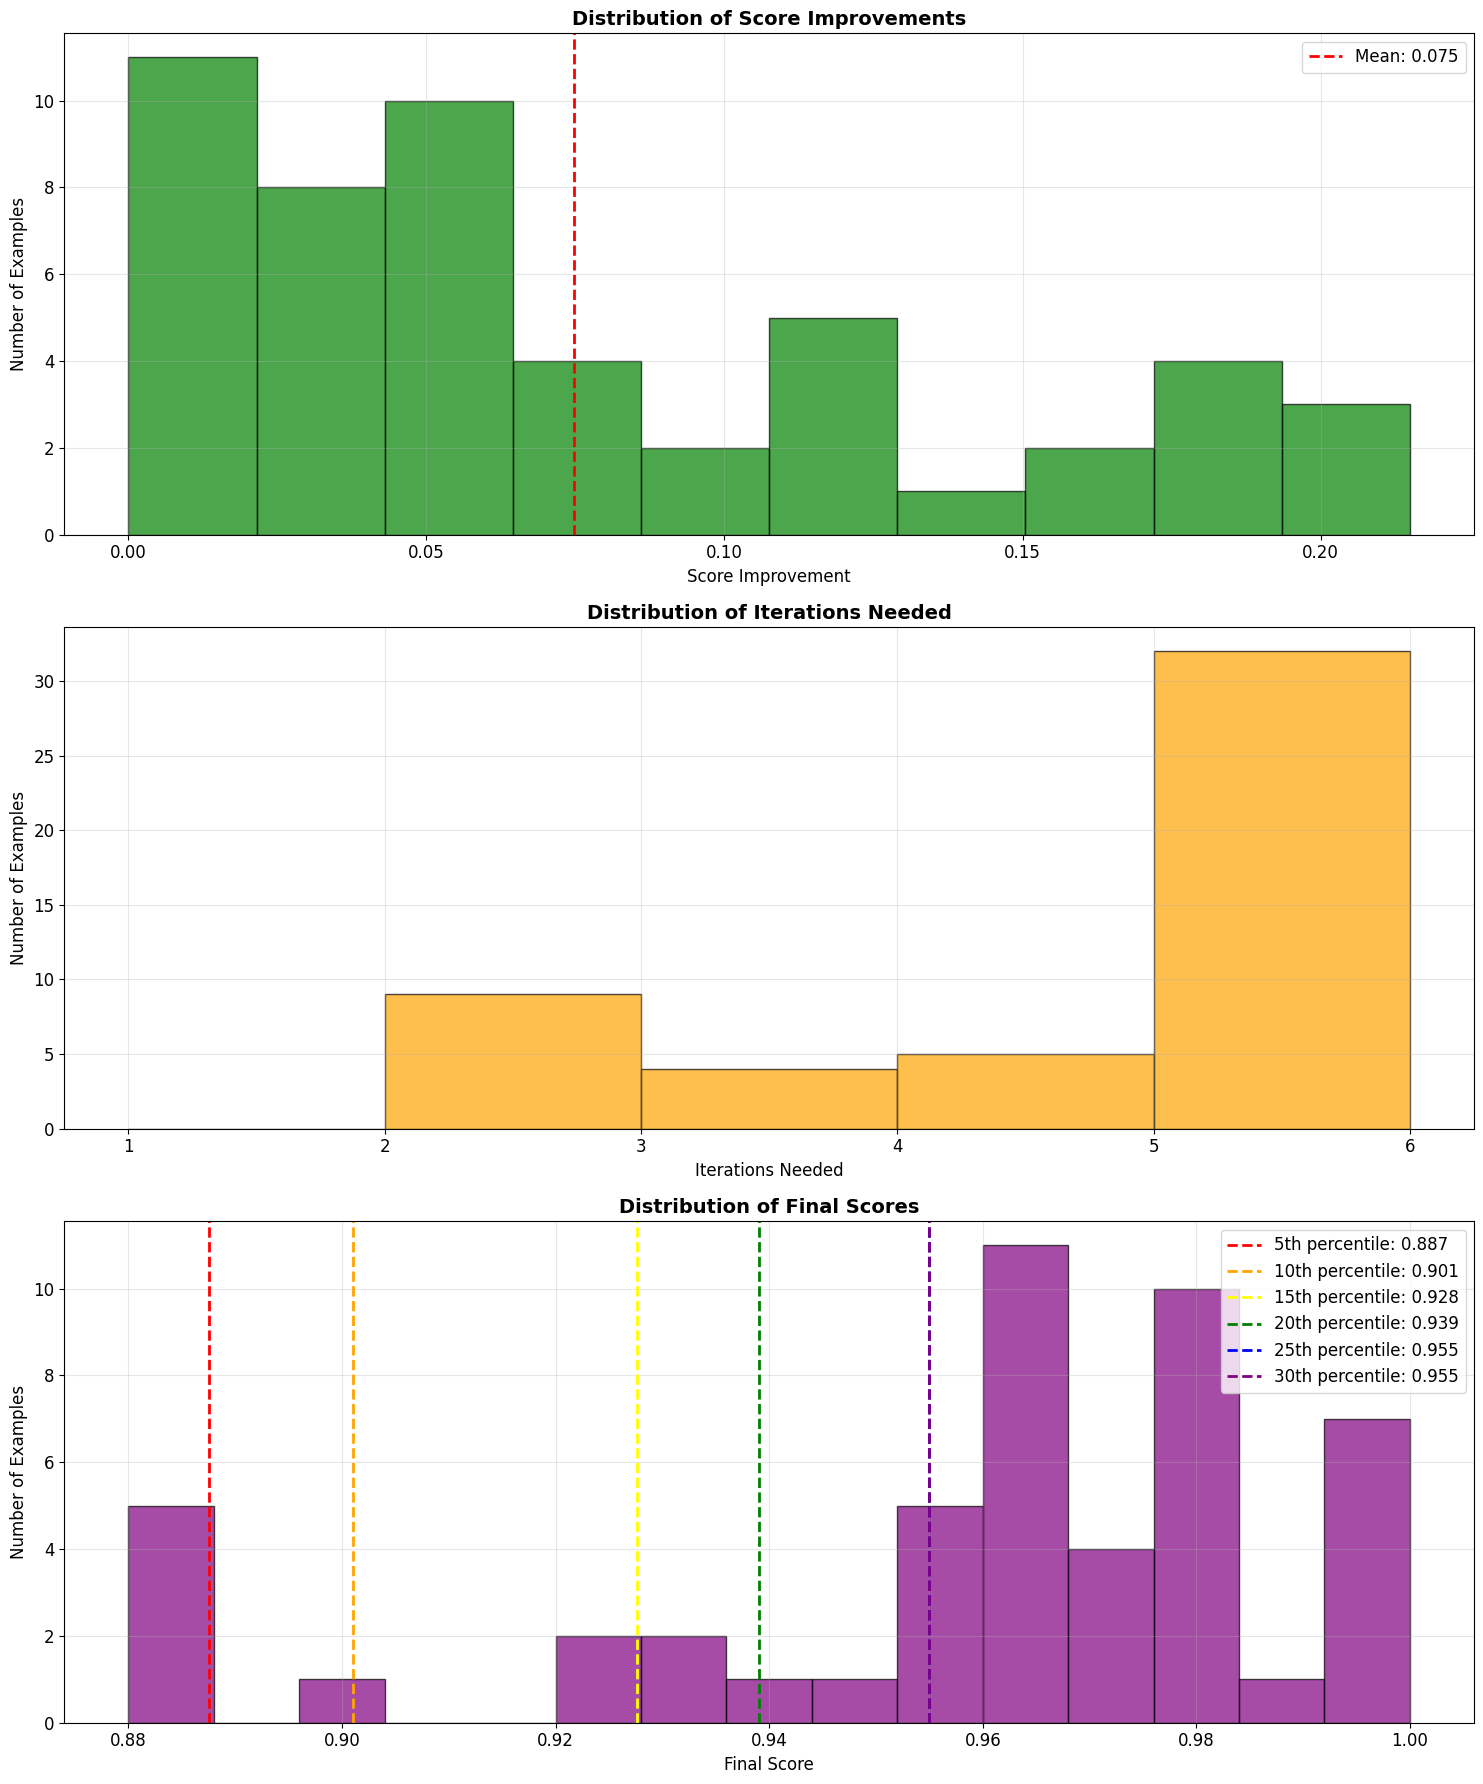


📈 IMPROVEMENT STATISTICS
Average improvement: 0.075
Median improvement: 0.054
Standard deviation of improvement: 0.063
Examples with positive improvement: 46/50

📊 PERCENTAGE IMPROVEMENTS BY ITERATION
�� INCREMENTAL IMPROVEMENTS (iteration to iteration):
  Iteration 1 → 2: +4.93% (0.884 → 0.927)
  Iteration 2 → 3: +1.12% (0.927 → 0.938)
  Iteration 3 → 4: +0.53% (0.938 → 0.943)
  Iteration 4 → 5: +0.17% (0.943 → 0.944)

📈 CUMULATIVE IMPROVEMENTS (from iteration 1):
  Iteration 1 (baseline): 0.884
  Iteration 2: +4.93% (0.884 → 0.927)
  Iteration 3: +6.10% (0.884 → 0.938)
  Iteration 4: +6.66% (0.884 → 0.943)
  Iteration 5: +6.84% (0.884 → 0.944)

�� TOTAL IMPROVEMENT: +6.84% (0.884 → 0.944)

🎯 FINAL SCORE DISTRIBUTION STATISTICS
Average final score: 0.959
Median final score: 0.963
Standard deviation: 0.032
Range: 0.880 - 1.000
Examples with score ≥ 0.9: 45/50 (90.0%)
Examples with score ≥ 0.92: 44/50 (88.0%)
Examples with score ≥ 0.94: 40/50 (80.0%)
Examples with score ≥ 0.96: 33/50 (

In [13]:
fig, ((ax1, ax2, ax3)) = plt.subplots(3, figsize=(15, 18))

# score improvements from first to last iteration
first_scores = df[df['iteration_number'] == 1]['current_best_score']
final_scores = final_iterations['current_best_score']
improvements = final_scores.values - first_scores.values

ax1.hist(improvements, bins=10, alpha=0.7, color='green', edgecolor='black')
ax1.set_xlabel('Score Improvement', fontsize=12)
ax1.set_ylabel('Number of Examples', fontsize=12)
ax1.set_title('Distribution of Score Improvements', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axvline(improvements.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {improvements.mean():.3f}')
ax1.legend()

# iterations needed distribution
iterations_needed = df.groupby('example_id')['iteration_number'].max()
ax2.hist(iterations_needed, bins=range(1, iterations_needed.max() + 2), 
         alpha=0.7, color='orange', edgecolor='black')
ax2.set_xlabel('Iterations Needed', fontsize=12)
ax2.set_ylabel('Number of Examples', fontsize=12)
ax2.set_title('Distribution of Iterations Needed', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# final score distribution
final_scores = final_iterations['current_best_score']
ax3.hist(final_scores, bins=15, alpha=0.7, color='purple', edgecolor='black')
ax3.set_xlabel('Final Score', fontsize=12)
ax3.set_ylabel('Number of Examples', fontsize=12)
ax3.set_title('Distribution of Final Scores', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# add vertical lines for key percentiles
percentiles = [5, 10, 15, 20, 25, 30]
percentile_values = [np.percentile(final_scores, p) for p in percentiles]
colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple']

for p, val, color in zip(percentiles, percentile_values, colors):
    ax3.axvline(val, color=color, linestyle='--', linewidth=2, 
                label=f'{p}th percentile: {val:.3f}')

ax3.legend()

plt.tight_layout()
plt.show()

# print improvement statistics
print(f"\n📈 IMPROVEMENT STATISTICS")
print("=" * 50)
print(f"Average improvement: {improvements.mean():.3f}")
print(f"Median improvement: {np.median(improvements):.3f}")
print(f"Standard deviation of improvement: {improvements.std():.3f}")
print(f"Examples with positive improvement: {np.sum(improvements > 0)}/{len(improvements)}")

# print percentage improvements by iteration
print(f"\n📊 PERCENTAGE IMPROVEMENTS BY ITERATION")
print("=" * 50)

# calculate percentage improvements between consecutive iterations
print("�� INCREMENTAL IMPROVEMENTS (iteration to iteration):")
for i in range(1, len(avg_scores_by_iteration)):
    current_score = avg_scores_by_iteration.iloc[i]['current_best_score']
    previous_score = avg_scores_by_iteration.iloc[i-1]['current_best_score']
    
    if previous_score > 0:
        percentage_improvement = ((current_score - previous_score) / previous_score) * 100
        print(f"  Iteration {i} → {i+1}: {percentage_improvement:+.2f}% ({previous_score:.3f} → {current_score:.3f})")
    else:
        print(f"  Iteration {i} → {i+1}: N/A (previous score was 0)")

# calculate cumulative improvements from first iteration
print(f"\n📈 CUMULATIVE IMPROVEMENTS (from iteration 1):")
first_score = avg_scores_by_iteration.iloc[0]['current_best_score']
print(f"  Iteration 1 (baseline): {first_score:.3f}")

for i in range(1, len(avg_scores_by_iteration)):
    current_score = avg_scores_by_iteration.iloc[i]['current_best_score']
    
    if first_score > 0:
        cumulative_improvement = ((current_score - first_score) / first_score) * 100
        print(f"  Iteration {i+1}: {cumulative_improvement:+.2f}% ({first_score:.3f} → {current_score:.3f})")
    else:
        print(f"  Iteration {i+1}: N/A (first score was 0)")

# calculate total percentage improvement from start to finish
final_avg = avg_scores_by_iteration.iloc[-1]['current_best_score']
total_percentage_improvement = ((final_avg - first_score) / first_score) * 100

print(f"\n�� TOTAL IMPROVEMENT: {total_percentage_improvement:+.2f}% ({first_score:.3f} → {final_avg:.3f})")

# print score distribution statistics
print(f"\n🎯 FINAL SCORE DISTRIBUTION STATISTICS")
print("=" * 50)
print(f"Average final score: {final_scores.mean():.3f}")
print(f"Median final score: {np.median(final_scores):.3f}")
print(f"Standard deviation: {final_scores.std():.3f}")
print(f"Range: {final_scores.min():.3f} - {final_scores.max():.3f}")

# show examples above different thresholds
thresholds = [0.9, 0.92, 0.94, 0.96, 0.98]
for threshold in thresholds:
    count_above = np.sum(final_scores >= threshold)
    percentage = (count_above / len(final_scores)) * 100
    print(f"Examples with score ≥ {threshold}: {count_above}/{len(final_scores)} ({percentage:.1f}%)")

## Judge Performance Analysis

Which judges are most critical? Which ones are easiest to satisfy?

👨‍⚖️ JUDGE PERFORMANCE ANALYSIS
Focus Relevance: 0.989
Coverage: 0.956
Structure: 0.906
Redundancy: 0.706


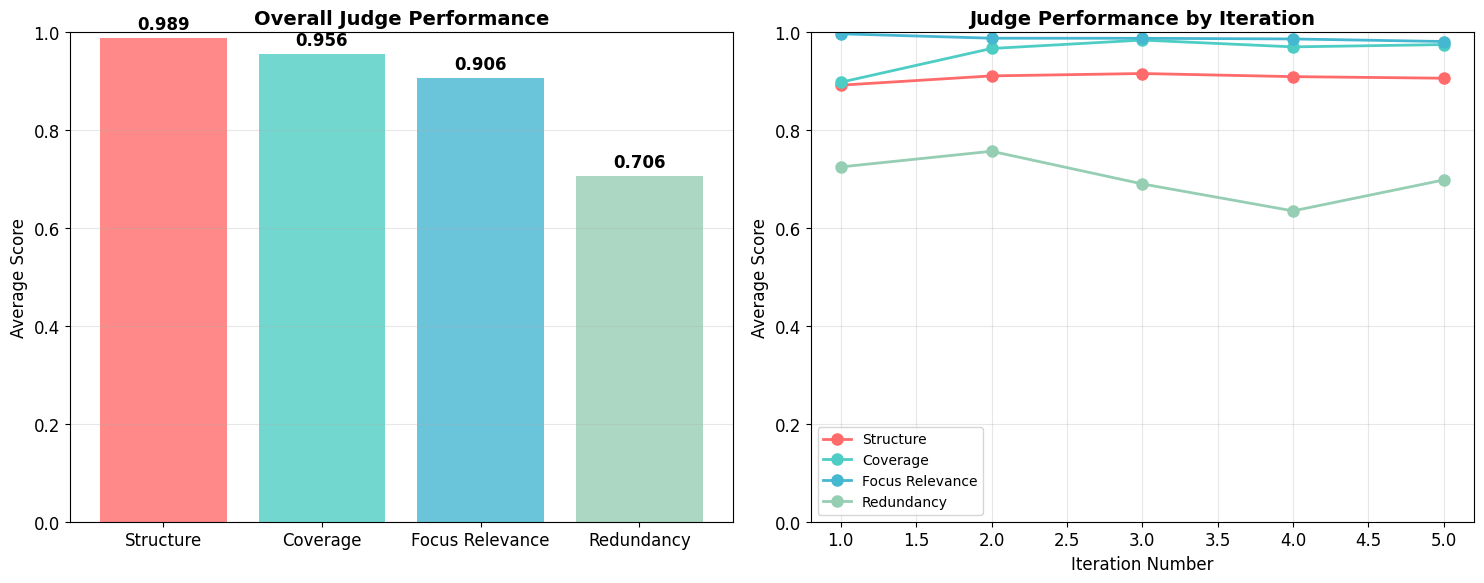


🎯 MOST CRITICAL JUDGE: Redundancy (Score: 0.706)
🎉 EASIEST JUDGE TO SATISFY: Focus Relevance (Score: 0.989)


In [14]:
# Analyze judge performance
judge_columns = ['structure_score', 'coverage_score', 'focus_relevance_score', 'redundancy_score']
judge_names = [col.replace('_score', '').replace('_', ' ').title() for col in judge_columns]

# Overall judge performance
judge_performance = df[judge_columns].mean().sort_values(ascending=False)

print("👨‍⚖️ JUDGE PERFORMANCE ANALYSIS")
print("=" * 50)
for judge, score in judge_performance.items():
    judge_name = judge.replace('_score', '').replace('_', ' ').title()
    print(f"{judge_name}: {score:.3f}")

# Plot judge performance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Overall judge performance
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars = ax1.bar(judge_names, judge_performance.values, color=colors, alpha=0.8)
ax1.set_ylabel('Average Score', fontsize=12)
ax1.set_title('Overall Judge Performance', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, 1)

# Add value labels on bars
for bar, value in zip(bars, judge_performance.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Judge performance by iteration
for i, col in enumerate(judge_columns):
    ax2.plot(avg_scores_by_iteration['iteration_number'], 
             avg_scores_by_iteration[col], 
             marker='o', linewidth=2, markersize=8,
             label=judge_names[i], color=colors[i])

ax2.set_xlabel('Iteration Number', fontsize=12)
ax2.set_ylabel('Average Score', fontsize=12)
ax2.set_title('Judge Performance by Iteration', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Which judge is most critical (lowest average score)
most_critical_judge = judge_performance.idxmin()
most_critical_name = most_critical_judge.replace('_score', '').replace('_', ' ').title()
print(f"\n🎯 MOST CRITICAL JUDGE: {most_critical_name} (Score: {judge_performance.min():.3f})")

# Which judge is easiest to satisfy (highest average score)
easiest_judge = judge_performance.idxmax()
easiest_name = easiest_judge.replace('_score', '').replace('_', ' ').title()
print(f"🎉 EASIEST JUDGE TO SATISFY: {easiest_name} (Score: {judge_performance.max():.3f})")

## Individual Example Analysis

Let's look at specific examples to understand the refinement process better.

🏆 TOP 5 PERFORMERS

1. example_025
--------------
Title: The origins of the 1977 Additional Proto...
Score: 1.000, Iterations: 4

2. example_040
--------------
Title: Common conditions the PERRLA test can de...
Score: 1.000, Iterations: 2

3. example_031
--------------
Title: Answering the Research Question
Score: 1.000, Iterations: 5

4. example_032
--------------
Title: INTRODUCTION
Score: 1.000, Iterations: 4

5. example_007
--------------
Title: Implications for research practice
Score: 1.000, Iterations: 2

📉 BOTTOM 5 PERFORMERS

1. example_027
--------------
Title: The Problem with Homework: It Highlights...
Score: 0.887, Iterations: 5

2. example_002
--------------
Title: Philosophy Program Struggles
Score: 0.887, Iterations: 5

3. example_039
--------------
Title: Putting a bubble in your mouth
Score: 0.887, Iterations: 5

4. example_009
--------------
Title: Ransomware as a Service
Score: 0.885, Iterations: 5

5. example_049
--------------
Title: Review your campaigns and lear

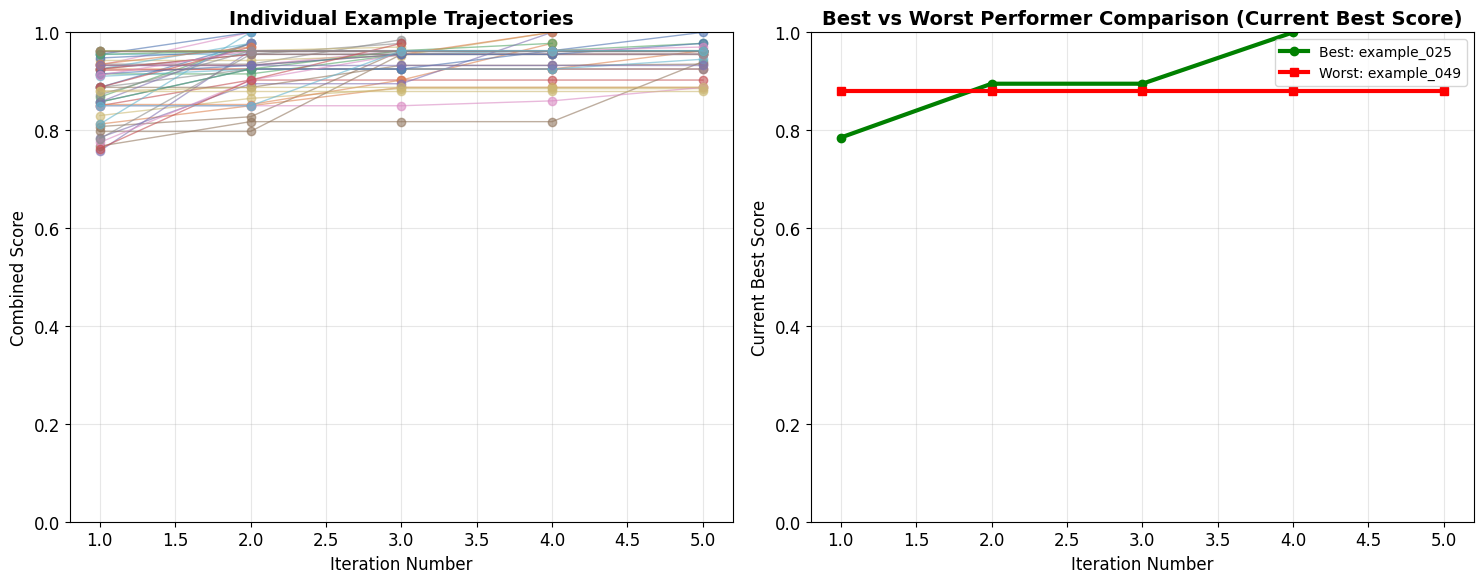

In [15]:
# get top and bottom performers
final_scores_summary = final_iterations[['example_id', 'title', 'current_best_score', 'total_iterations']].sort_values('current_best_score', ascending=False)

print("🏆 TOP 5 PERFORMERS")
print("=" * 50 + "\n")
for i, (_, row) in enumerate(final_scores_summary.head(5).iterrows(), 1):
    print(f"{i}. {row['example_id']}")
    print("-" * 14)
    print(f"Title: {row['title'][:40]}{'...' if len(row['title']) > 40 else ''}")
    print(f"Score: {row['current_best_score']:.3f}, Iterations: {row['total_iterations']}\n")

print("📉 BOTTOM 5 PERFORMERS")
print("=" * 50 + "\n")
for i, (_, row) in enumerate(final_scores_summary.tail(5).iterrows(), 1):
    print(f"{i}. {row['example_id']}")
    print("-" * 14)
    print(f"Title: {row['title'][:40]}{'...' if len(row['title']) > 40 else ''}")
    print(f"Score: {row['current_best_score']:.3f}, Iterations: {row['total_iterations']}\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# plot all example trajectories
for example_id in df['example_id'].unique():
    example_data = df[df['example_id'] == example_id].sort_values('iteration_number')
    ax1.plot(example_data['iteration_number'], example_data['current_best_score'], 
             marker='o', alpha=0.6, linewidth=1)

ax1.set_xlabel('Iteration Number', fontsize=12)
ax1.set_ylabel('Combined Score', fontsize=12)
ax1.set_title('Individual Example Trajectories', fontsize=14, fontweight='bold')

ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# best vs worst performer comparison
best_example = final_scores_summary.iloc[0]['example_id']
worst_example = final_scores_summary.iloc[-1]['example_id']

best_data = df[df['example_id'] == best_example].sort_values('iteration_number')
worst_data = df[df['example_id'] == worst_example].sort_values('iteration_number')

ax2.plot(best_data['iteration_number'], best_data['current_best_score'], 
         marker='o', linewidth=3, label=f'Best: {best_example}', color='green')
ax2.plot(worst_data['iteration_number'], worst_data['current_best_score'], 
         marker='s', linewidth=3, label=f'Worst: {worst_example}', color='red')

ax2.set_xlabel('Iteration Number', fontsize=12)
ax2.set_ylabel('Current Best Score', fontsize=12)
ax2.set_title('Best vs Worst Performer Comparison (Current Best Score)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Best Iteration Analysis

Understanding which iteration produced the best results for each example.

In [16]:
best_iterations = df['current_best_iteration'].value_counts().reset_index()
best_iterations.columns = ['iteration', 'count']
best_iterations['percentage'] = best_iterations['count'] / best_iterations['count'].sum() * 100
best_iterations['rolling_percentage'] = best_iterations['percentage'].cumsum().round(2)

best_iterations

,iteration,count,percentage,rolling_percentage
0,1,85,40.476190,40.48
1,2,70,33.333333,73.81
2,3,37,17.619048,91.43
3,4,9,4.285714,95.71
4,5,9,4.285714,100.00


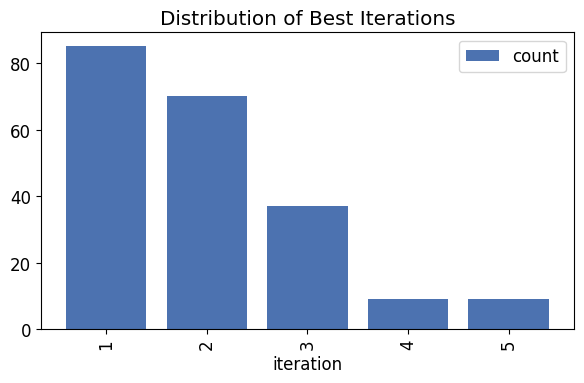

In [17]:
best_iterations.plot(kind='bar', x='iteration', y='count', width=0.8).figure.set_size_inches(6, 4)
plt.title("Distribution of Best Iterations")
plt.tight_layout()  # This helps with spacing around the plot
plt.show()

## Convergence Analysis

How often does the system converge early? What patterns do we see?

In [18]:
convergence_data = final_iterations[['example_id', 'converged_early', 'total_iterations', 'current_best_score']]

print("🎯 CONVERGENCE ANALYSIS")
print("=" * 50)
print(f"Examples that converged early: {convergence_data['converged_early'].sum()}")
print(f"Examples that reached max iterations: {(~convergence_data['converged_early']).sum()}")
print(f"Convergence rate: {convergence_data['converged_early'].mean():.2%}")

# compare scores between converged and non-converged examples
converged_scores = convergence_data[convergence_data['converged_early']]['current_best_score']
non_converged_scores = convergence_data[~convergence_data['converged_early']]['current_best_score']

print(f"\n📊 SCORE COMPARISON")
print("=" * 50)
print(f"Average score (converged early): {converged_scores.mean():.3f}")
print(f"Average score (reached max): {non_converged_scores.mean():.3f}")
print(f"Score difference: {converged_scores.mean() - non_converged_scores.mean():.3f}")

🎯 CONVERGENCE ANALYSIS
Examples that converged early: 22
Examples that reached max iterations: 28
Convergence rate: 44.00%

📊 SCORE COMPARISON
Average score (converged early): 0.984
Average score (reached max): 0.939
Score difference: 0.045


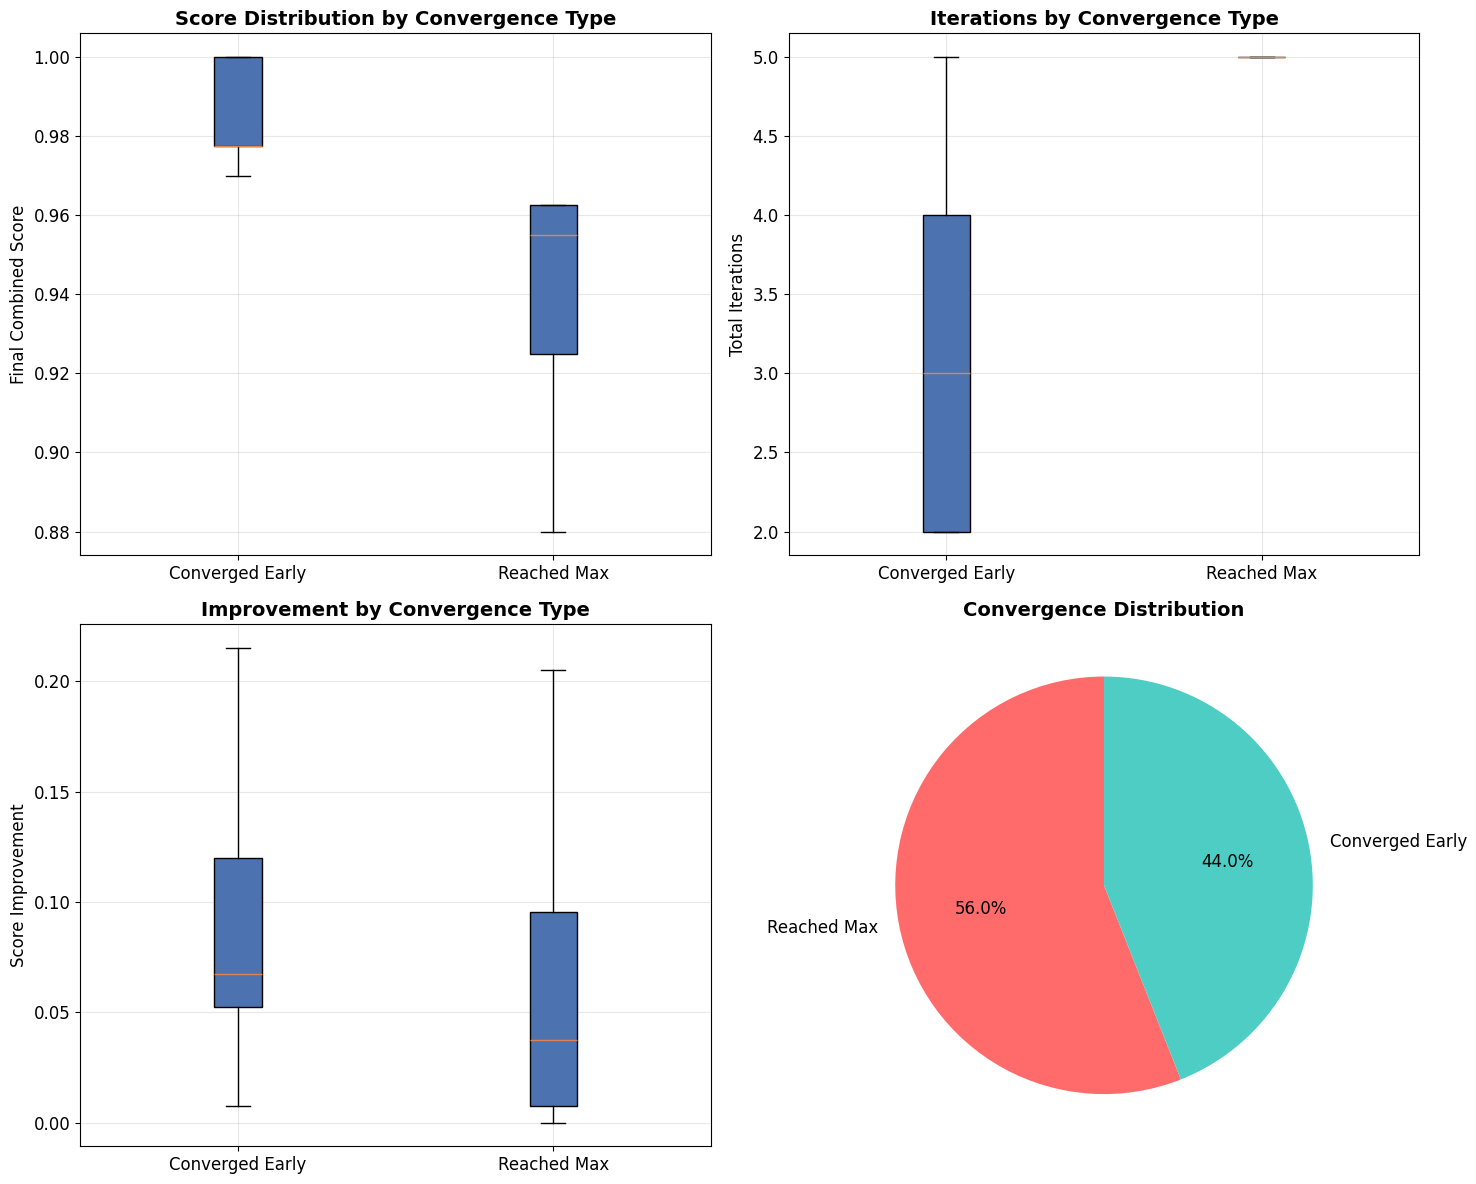

In [19]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Convergence vs Non-convergence scores
ax1.boxplot([converged_scores, non_converged_scores], 
            labels=['Converged Early', 'Reached Max'], patch_artist=True)
ax1.set_ylabel('Final Combined Score', fontsize=12)
ax1.set_title('Score Distribution by Convergence Type', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Plot 2: Iterations needed by convergence type
converged_iterations = convergence_data[convergence_data['converged_early']]['total_iterations']
non_converged_iterations = convergence_data[~convergence_data['converged_early']]['total_iterations']

ax2.boxplot([converged_iterations, non_converged_iterations], 
            labels=['Converged Early', 'Reached Max'], patch_artist=True)
ax2.set_ylabel('Total Iterations', fontsize=12)
ax2.set_title('Iterations by Convergence Type', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: Score improvement by convergence type
converged_improvements = []
non_converged_improvements = []

for example_id in convergence_data['example_id']:
    example_data = df[df['example_id'] == example_id]
    first_score = example_data[example_data['iteration_number'] == 1]['current_best_score'].iloc[0]
    final_score = example_data[example_data['is_final_iteration'] == True]['current_best_score'].iloc[0]
    improvement = final_score - first_score
    
    if convergence_data[convergence_data['example_id'] == example_id]['converged_early'].iloc[0]:
        converged_improvements.append(improvement)
    else:
        non_converged_improvements.append(improvement)

ax3.boxplot([converged_improvements, non_converged_improvements], 
            labels=['Converged Early', 'Reached Max'], patch_artist=True)
ax3.set_ylabel('Score Improvement', fontsize=12)
ax3.set_title('Improvement by Convergence Type', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: Convergence rate pie chart
convergence_counts = convergence_data['converged_early'].value_counts()
ax4.pie(convergence_counts.values, labels=['Reached Max', 'Converged Early'], 
        autopct='%1.1f%%', startangle=90, colors=['#FF6B6B', '#4ECDC4'])
ax4.set_title('Convergence Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Text Length Analysis

Does the length of the original text affect refinement performance?

In [20]:
# Analyze relationship between text length and performance
length_performance = final_iterations[['example_id', 'original_text_length', 'current_best_score', 'total_iterations']]

# Calculate correlations
length_score_corr = length_performance['original_text_length'].corr(length_performance['current_best_score'])
length_iterations_corr = length_performance['original_text_length'].corr(length_performance['total_iterations'])

print("📏 TEXT LENGTH ANALYSIS")
print("=" * 50)
print(f"Correlation between text length and final score: {length_score_corr:.3f}")
print(f"Correlation between text length and iterations needed: {length_iterations_corr:.3f}")
print(f"\nText length statistics:")
print(f"  Mean: {length_performance['original_text_length'].mean():.0f} characters")
print(f"  Median: {length_performance['original_text_length'].median():.0f} characters")
print(f"  Min: {length_performance['original_text_length'].min():.0f} characters")
print(f"  Max: {length_performance['original_text_length'].max():.0f} characters")

📏 TEXT LENGTH ANALYSIS
Correlation between text length and final score: 0.222
Correlation between text length and iterations needed: -0.039

Text length statistics:
  Mean: 2002 characters
  Median: 1882 characters
  Min: 881 characters
  Max: 3922 characters


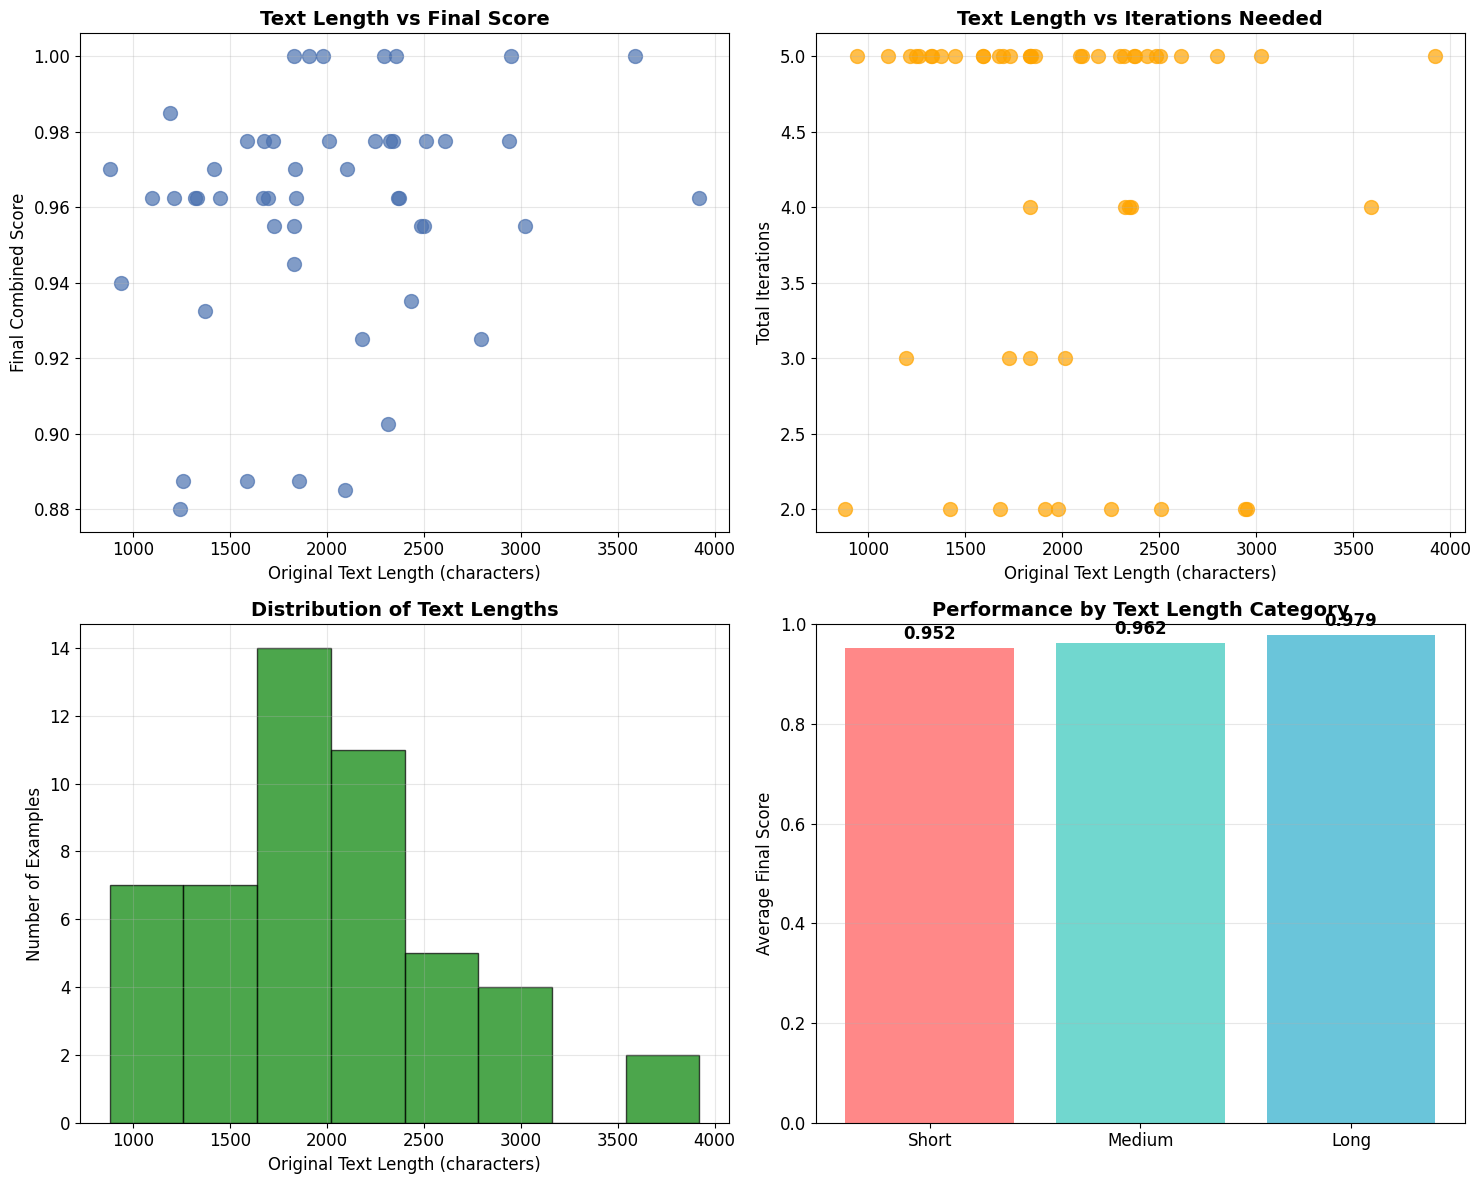

In [21]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Text length vs final score
ax1.scatter(length_performance['original_text_length'], length_performance['current_best_score'], 
            alpha=0.7, s=100)
ax1.set_xlabel('Original Text Length (characters)', fontsize=12)
ax1.set_ylabel('Final Combined Score', fontsize=12)
ax1.set_title('Text Length vs Final Score', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Plot 2: Text length vs iterations needed
ax2.scatter(length_performance['original_text_length'], length_performance['total_iterations'], 
            alpha=0.7, s=100, color='orange')
ax2.set_xlabel('Original Text Length (characters)', fontsize=12)
ax2.set_ylabel('Total Iterations', fontsize=12)
ax2.set_title('Text Length vs Iterations Needed', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: Text length distribution
ax3.hist(length_performance['original_text_length'], bins=8, alpha=0.7, color='green', edgecolor='black')
ax3.set_xlabel('Original Text Length (characters)', fontsize=12)
ax3.set_ylabel('Number of Examples', fontsize=12)
ax3.set_title('Distribution of Text Lengths', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: Performance by text length category
length_performance['length_category'] = pd.cut(length_performance['original_text_length'], 
                                              bins=3, labels=['Short', 'Medium', 'Long'])
category_performance = length_performance.groupby('length_category')['current_best_score'].mean()

bars = ax4.bar(category_performance.index, category_performance.values, 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
ax4.set_ylabel('Average Final Score', fontsize=12)
ax4.set_title('Performance by Text Length Category', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_ylim(0, 1)

# Add value labels
for bar, value in zip(bars, category_performance.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Key Insights and Summary

Let's summarize the most interesting findings from our analysis.

In [22]:
print("🔍 KEY INSIGHTS FROM REFINEMENT ANALYSIS")
print("=" * 60)
print()

print("📈 SCORE IMPROVEMENT PATTERNS:")
print(f"  • Average improvement: {improvements.mean():.3f}")
print(f"  • {np.sum(improvements > 0)}/{len(improvements)} examples showed positive improvement")
print(f"  • {np.sum(improvements < 0)}/{len(improvements)} examples showed negative improvement")
print()

print("👨‍⚖️ JUDGE PERFORMANCE:")
print(f"  • Most critical judge: {most_critical_name} ({judge_performance.min():.3f})")
print(f"  • Easiest judge: {easiest_name} ({judge_performance.max():.3f})")
print(f"  • Judge score range: {judge_performance.max() - judge_performance.min():.3f}")
print()

print("🎯 CONVERGENCE BEHAVIOR:")
print(f"  • Convergence rate: {convergence_rate:.2%}")
print(f"  • Average iterations needed: {df.groupby('example_id')['iteration_number'].max().mean():.2f}")
print(f"  • Converged examples scored {converged_scores.mean() - non_converged_scores.mean():.3f} higher on average")
print()

print("📏 TEXT LENGTH EFFECTS:")
print(f"  • Text length vs score correlation: {length_score_corr:.3f}")
print(f"  • Text length vs iterations correlation: {length_iterations_corr:.3f}")
print()

print("🏆 PERFORMANCE RANGE:")
print(f"  • Best final score: {final_iterations['combined_score'].max():.3f}")
print(f"  • Worst final score: {final_iterations['combined_score'].min():.3f}")
print(f"  • Score range: {final_iterations['combined_score'].max() - final_iterations['combined_score'].min():.3f}")
print()

🔍 KEY INSIGHTS FROM REFINEMENT ANALYSIS

📈 SCORE IMPROVEMENT PATTERNS:
  • Average improvement: 0.075
  • 46/50 examples showed positive improvement
  • 0/50 examples showed negative improvement

👨‍⚖️ JUDGE PERFORMANCE:
  • Most critical judge: Redundancy (0.706)
  • Easiest judge: Focus Relevance (0.989)
  • Judge score range: 0.283

🎯 CONVERGENCE BEHAVIOR:
  • Convergence rate: 44.00%
  • Average iterations needed: 4.20
  • Converged examples scored 0.045 higher on average

📏 TEXT LENGTH EFFECTS:
  • Text length vs score correlation: 0.222
  • Text length vs iterations correlation: -0.039

🏆 PERFORMANCE RANGE:
  • Best final score: 1.000
  • Worst final score: 0.675
  • Score range: 0.325

